# Homework 3

## Group Number: 112
  
### Group Members:
- Duarte Rebelo de São José: ist1103708
- Tiago Ramos da Rocha Neves Caixinha: ist1102437

# Imports and data loading

In [109]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

data = pd.read_csv("winequality-red.csv", sep=";")

X = data.drop("quality", axis=1)
y = data["quality"]

# Problem 1

### Defining and training the MLP Regressor

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
residues = []

for seed in range(1, 11):
    mlp_regressor = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', random_state=seed, early_stopping=True, validation_fraction=0.2)
    mlp_regressor.fit(X_train, y_train)
    predictions = mlp_regressor.predict(X_test)
    residues.extend(np.abs(predictions - y_test))

C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\A

### Plotting the distribution of residues


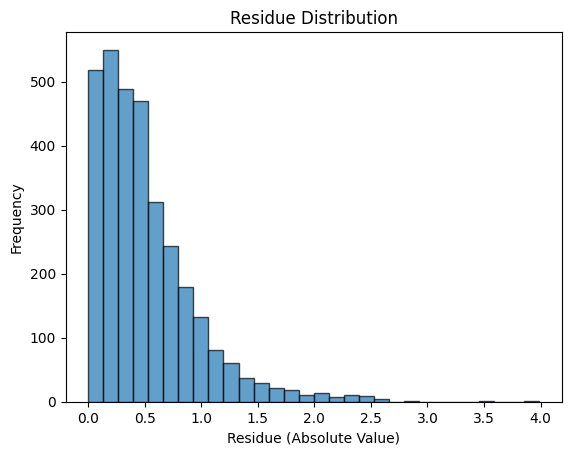

In [111]:
plt.hist(residues, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Residue (Absolute Value)")
plt.ylabel("Frequency")
plt.title("Residue Distribution")
plt.show()

# Problem 2

### Assessing the impact of rounding and bounding on MAE

In [118]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np

impacts_on_mae_original = []
impacts_on_mae_rounded = []
impacts_on_mae_bounded = []

for random_state in range(11):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    mlp_regressor = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', random_state=random_state, early_stopping=True, validation_fraction=0.2)
    mlp_regressor.fit(X_train, y_train)
    
    predictions = mlp_regressor.predict(X_test)
    
    rounded_predictions = np.round(predictions)
    
    bounded_predictions = np.clip(predictions, 3, 8)
    
    mae_original = mean_absolute_error(y_test, predictions)
    mae_rounded = mean_absolute_error(y_test, rounded_predictions)
    mae_bounded = mean_absolute_error(y_test, bounded_predictions)
    
    impacts_on_mae_original.append(mae_original)
    impacts_on_mae_rounded.append(mae_rounded)
    impacts_on_mae_bounded.append(mae_bounded)

avg_impact_original = np.mean(impacts_on_mae_original)
avg_impact_rounded = np.mean(impacts_on_mae_rounded)
avg_impact_bounded = np.mean(impacts_on_mae_bounded)

print(f"Average Impact on MAE (Original): {avg_impact_original:.4f}")
print(f"Average Impact on MAE (Rounded): {avg_impact_rounded:.4f}")
print(f"Average Impact on MAE (Bounded): {avg_impact_bounded:.4f}")


C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\A

Average Impact on MAE (Original): 0.5294
Average Impact on MAE (Rounded): 0.4668
Average Impact on MAE (Bounded): 0.5294


C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# Problem 3

### Assessing the impact of replacing early stopping with fixed iterations

C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\dddua\AppD

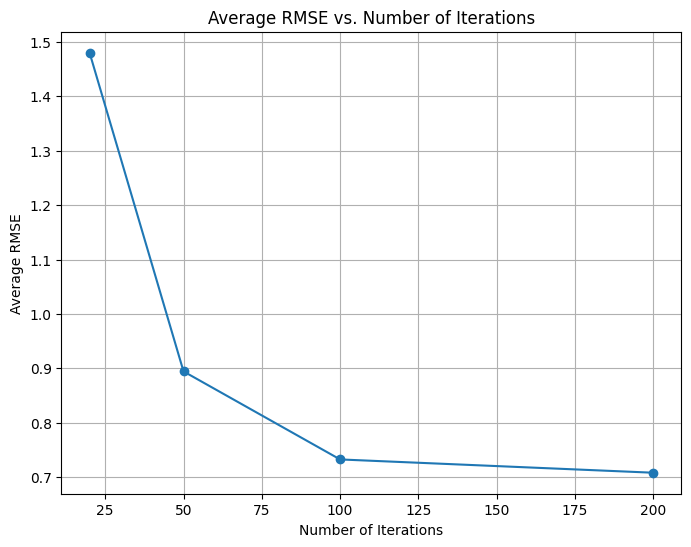

20: Average RMSE = 1.4798416064124404
50: Average RMSE = 0.894444581855607
100: Average RMSE = 0.7327544252242888
200: Average RMSE = 0.7083487358666273


In [115]:
import matplotlib.pyplot as plt
import numpy as np

iteration_numbers = [20, 50, 100, 200]
rmse_scores = []

for iterations in iteration_numbers:
    rmse_run = []
    for seed in range(1, 11):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
        
        mlp_regressor = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', max_iter=iterations)
        mlp_regressor.fit(X_train, y_train)
        predictions = mlp_regressor.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        rmse_run.append(rmse)
    rmse_scores.append(rmse_run)

# Plot RMSE values
plt.figure(figsize=(8, 6))
avg_rmse = np.mean(rmse_scores, axis=1)
plt.plot(iteration_numbers, avg_rmse, marker='o', linestyle='-')
plt.xlabel('Number of Iterations')
plt.ylabel('Average RMSE')
plt.title('Average RMSE vs. Number of Iterations')
plt.grid(True)
plt.show()

# Print RMSE values
for i, iterations in enumerate(iteration_numbers):
    print(f"{iterations}: Average RMSE = {avg_rmse[i]}")


# Problem 4

### Commenting on the results obtained in the previous question


Replacing early stopping with a well-defined number of iterations may impact model performance significantly. The RMSE results from question 3 show that finding the right number of iterations is a delicate balance. Too few iterations may lead to underfitting, while too many iterations may result in overfitting. Early stopping serves as a safeguard against overfitting by monitoring validation performance, and without it, the model may struggle to generalize effectively, as indicated by the RMSE improvements with increased iterations. Careful hyperparameter tuning is essential to find the optimal number of iterations for a given dataset and model complexity.